In [4]:
# %load_ext cuml.accel

# Credit Card Fraud Detection 
## 1. Introduction
Credit Card transaction fraud detection is an *imbalanced classification problem*. Since, fraudulent transactions occurs rarely w.r.t legitmate ones it became more challenging.

**Notebook Application**:  
The notebook solves problems using:
* XGBoost algorithm for fraud detection.
* MLflow to track mlprocess and results.

In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE 
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score,accuracy_score,f1_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, TargetEncoder


## 2. Data Loading and Initial Overview
* Loading the dataset and performing an initial check is the first step in any ML project.  
load dataset and perform initial screening is first step in any ML projet.
Analyzing and understanding dataset structure that will guides preprocessing

In [6]:
# load dataset
df = pd.read_csv('credit_card_transactions.csv')
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode'],
      dtype='object')

**2. Dataset Overview**
This dataset contains credit crard transaction details along with merchant, customer details.

#### Columns (before processing):
* Unnamed: 0 -- index column
* cc_num: Credit card number.
* first, last: Customer first/last name 
* trans_date_trans_time: Transaction date & time
* unix_time: Unix timestamp 

* dob:  date of birth of customer
* gender:  gender.

* street, city, state, zip, city_pop: Location-related features.

* lat, long: Customer latitude/longitude.

* merch_lat, merch_long: Merchant latitude/longitude.

* merchant: Merchant name.

* category: transaction type.

* amt: Transaction amount.

* job: Customer job.

* merch_zipcode: Merchant’s ZIP code.

* is_fraud: Target variable 


In [7]:
df = df.drop(columns=["Unnamed: 0", "cc_num", "first", "last",'lon','street','merch_zipcode','city_pop','zip','unix_time'], errors="ignore")


## 3. Feature Engineering, Feature selection and data cleaning
***Dropped columns:***
Unnamed: 0

cc_num

first, last, street, merch_zipcode, city_pop, zip, unix_time

* Removing unnecessary columns reduces noises and speedup training.

***Date and time processing***
* convert datetime to strings

and extract new features from datetime:
* trans_year → transaction year

* trans_month → transaction month

* trans_day → transaction day

* trans_hour → Hour of the day 

* trans_weekday → Day of the week 

* is_weekend → Boolean 

* ***Age Feature from dob*** age is derrived from dob, makes more reasonable output.
* ***Categorical Encoding***

In [8]:
# datetime management
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], 
                                             format="%Y-%m-%d %H:%M:%S",
                                             errors="coerce")
df['dob'] = pd.to_datetime(df['dob'], errors="coerce")

In [9]:
# transaction time feature
df['trans_year'] = df['trans_date_trans_time'].dt.year
df['trans_month'] = df['trans_date_trans_time'].dt.month
df['trans_day'] = df['trans_date_trans_time'].dt.day
df['trans_hour'] = df['trans_date_trans_time'].dt.hour
df['trans_weekday'] = df['trans_date_trans_time'].dt.weekday
df['is_weekend'] = df['trans_date_trans_time'].dt.weekday >= 5


#### Customer age

In [10]:
# age from dob
df['age'] = (df['trans_date_trans_time'].dt.year - df[ 
  'dob'].dt.year)

### Data types and features
#### Numerical columns
* amt: Transaction amount

* lat, long: Customer location

* merch_lat, merch_long: Merchant location

* trans_year, trans_month, trans_day, trans_hour, trans_weekday

* is_weekend

* age


### Categorical columns
* gender

* category

* state

* job

* merchant

---> Encoded using:
* LabelEncoder: for binary
* OneHotEncoder: feature with low cardinal fcategory
* TargetEncoder: feature with high cardinal category


In [11]:
df = df.drop(columns=['trans_date_trans_time','dob'])
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 20 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   merchant       1296675 non-null  object 
 1   category       1296675 non-null  object 
 2   amt            1296675 non-null  float64
 3   gender         1296675 non-null  object 
 4   city           1296675 non-null  object 
 5   state          1296675 non-null  object 
 6   lat            1296675 non-null  float64
 7   long           1296675 non-null  float64
 8   job            1296675 non-null  object 
 9   trans_num      1296675 non-null  object 
 10  merch_lat      1296675 non-null  float64
 11  merch_long     1296675 non-null  float64
 12  is_fraud       1296675 non-null  int64  
 13  trans_year     1296675 non-null  int32  
 14  trans_month    1296675 non-null  int32  
 15  trans_day      1296675 non-null  int32  
 16  trans_hour     1296675 non-null  int32  
 17  trans_we

In [12]:
num_cols = ['amt', 'lat', 'long', 'merch_lat', 'merch_long',
                    'trans_year', 'trans_month', 'trans_day', 'trans_hour',
                    'trans_weekday', 'is_weekend', 'age']
                                                            
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

In [13]:
cat_low_cols = ['gender', 'category', 'state']
cat_high_cols = ['merchant', 'city', 'job']
for col in cat_low_cols + cat_high_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

In [14]:

# Convert 'amt' to numeric, coercing errors
df['amt'] = pd.to_numeric(df['amt'], errors='coerce')

# Encode categorical
cat_low_cols = ['gender', 'category', 'state']
cat_high_cols = ['merchant', 'city']
num_cols = ['amt', 'lat', 'long', 
                    'trans_year', 'trans_month', 'trans_day', 'trans_hour',
                    'trans_weekday', 'is_weekend', 'age']

# missing values
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_low_cols + cat_high_cols] = df[cat_low_cols + cat_high_cols].fillna("Unknown")

In [15]:
y = df['is_fraud']
X = df.drop('is_fraud',axis=1)


In [16]:

y.isna()

0          False
1          False
2          False
3          False
4          False
           ...  
1296670    False
1296671    False
1296672    False
1296673    False
1296674    False
Name: is_fraud, Length: 1296675, dtype: bool

### Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42,stratify=y)

In [20]:
print(df.nunique())

merchant             693
category              14
amt                52928
gender                 2
city                 894
state                 51
lat                  968
long                 969
job                  494
trans_num        1296675
merch_lat        1247805
merch_long       1275745
is_fraud               2
trans_year             2
trans_month           12
trans_day             31
trans_hour            24
trans_weekday          7
is_weekend             2
age                   83
dtype: int64


In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), [c for c in num_cols if c in X_train.columns]),
        ('cat_low', OneHotEncoder(handle_unknown='ignore'), [c for c in cat_low_cols if c in X_train.columns])
    ]
)

In [22]:
X_train_low = preprocessor.fit_transform(X_train, y_train)
X_test_low = preprocessor.transform(X_test)

In [23]:
print(X_train_low.shape)
print(X_test_low.shape)
print(X_train_low.dtype)
print(X_test_low.dtype)



(1037340, 77)
(259335, 77)
float64
float64


In [ ]:
tar_enc = TargetEncoder()
X_train_high = tar_enc.fit_transform(X_train[cat_high_cols],y_train)
X_test_high = tar_enc.transform(X_test[cat_high_cols])



In [25]:
print(X_train_high.shape)
print(X_test_high.shape)
print(X_train_high.dtype)
print(X_test_high.dtype)

(1037340, 2)
(259335, 2)
float64
float64


In [ ]:
from scipy.sparse import issparse

if issparse(X_train_low):
    X_train_low = X_train_low.toarray()
if issparse(X_test_low):
    X_test_low = X_test_low.toarray()

if X_train_high.ndim == 1:
    X_train_high = X_train_high.reshape(-1, 1)
if X_test_high.ndim == 1:
    X_test_high = X_test_high.reshape(-1, 1)

In [ ]:

import numpy as np
X_train_processed = np.hstack([X_train_low, X_train_high])
X_test_processed = np.hstack([X_test_low, X_test_high])

In [ ]:
print("X_train_low:", type(X_train_low), X_train_low.shape, f"ndim: {X_train_low.ndim}")
print("X_train_high:", type(X_train_high), X_train_high.shape, f"ndim: {X_train_high.ndim}")

if issparse(X_train_low):
    print("X_train_low is sparse")
if issparse(X_train_high):
    print("X_train_high is sparse")

X_train_low: <class 'numpy.ndarray'> (1037340, 77) ndim: 2
X_train_high: <class 'numpy.ndarray'> (1037340, 2) ndim: 2


In [29]:
df.select_dtypes(include=['object']).columns

Index(['merchant', 'category', 'gender', 'city', 'state', 'job', 'trans_num'], dtype='object')

In [30]:
X.dtypes

merchant          object
category          object
amt              float64
gender            object
city              object
state             object
lat              float64
long             float64
job               object
trans_num         object
merch_lat        float64
merch_long       float64
trans_year         int32
trans_month        int32
trans_day          int32
trans_hour         int32
trans_weekday      int32
is_weekend          bool
age                int32
dtype: object

### Handling Class Imbalance
SMOTE is used in training data set.  It generates synthetic samples for minority class.

In [31]:
print("Before SMOTE:")
print(y_train.value_counts())
print(f"Dataset shape: {X_train_processed.shape}")

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())
print(f"Balanced dataset shape: {X_train_balanced.shape}")

Before SMOTE:
is_fraud
0    1031335
1       6005
Name: count, dtype: int64
Dataset shape: (1037340, 79)

After SMOTE:
is_fraud
0    1031335
1    1031335
Name: count, dtype: int64
Balanced dataset shape: (2062670, 79)


### Model Training
* Model used: XGBoost Classifier.
----> pipeline:
* column transformer for handling cateegorical data
* standardscaler standardizes numerical values


## Model Evaluation
* Since, this is classification problem and also have imbalanced dataset. so, model evaluation goes beyond accuracy
Key metrics:  
- **Confusion Matrix** → fraud vs non fraud detetion
- **ROC-AUC Score** → Measures overall discrimination ability.  
- **F1-score** → Used in imbalanced dataset. Balances precision and recall 

In [32]:
# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=300,       
    max_depth=6,           
    learning_rate=0.1,      
    subsample=0.8,          
    colsample_bytree=0.8,   
    random_state=42,
)

# Train the model
xgb_model.fit(X_train_balanced, y_train_balanced)

# Predictions
y_pred = xgb_model.predict(X_test_processed)
y_prob = xgb_model.predict_proba(X_test_processed)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.75      0.90      0.81      1501

    accuracy                           1.00    259335
   macro avg       0.87      0.95      0.91    259335
weighted avg       1.00      1.00      1.00    259335

ROC-AUC: 0.99879117746444


In [33]:
import shap
import matplotlib.pyplot as plt


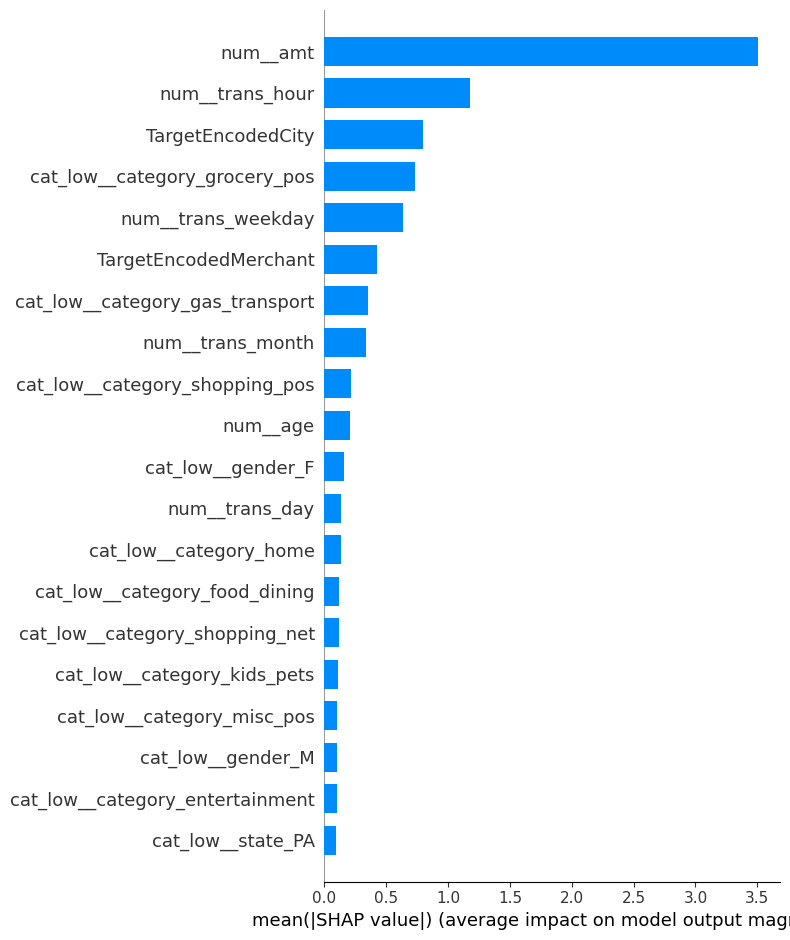

<Figure size 640x480 with 0 Axes>

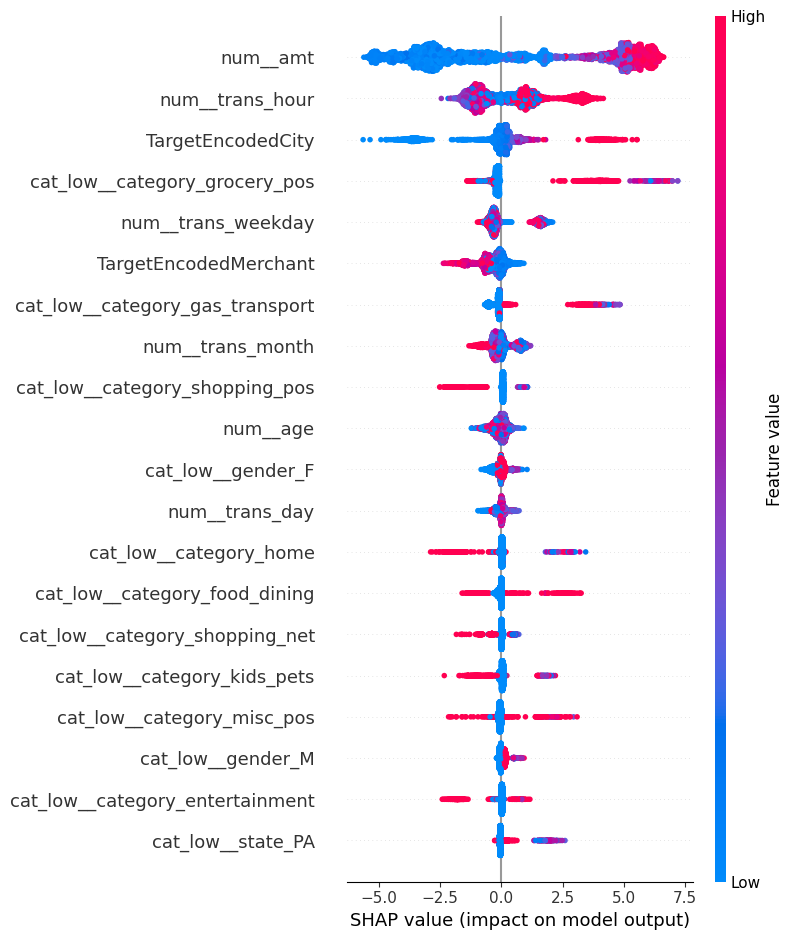

<Figure size 640x480 with 0 Axes>

In [ ]:
feature_names = list(preprocessor.get_feature_names_out())

feature_names.extend(['TargetEncodedMerchant', 'TargetEncodedCity'])

X_train_balanced_df = pd.DataFrame(X_train_balanced, columns=feature_names)

sample = X_train_balanced_df.sample(5000, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(sample)

# Plots
plt.figure(figsize=(4, 3))  
shap.summary_plot(shap_values.values, sample, plot_type="bar")
plt.tight_layout()
plt.figure(figsize=(4, 3))  
shap.summary_plot(shap_values.values, sample)
plt.tight_layout()

In [ ]:
import mlflow

In [ ]:

import os
from itertools import product


mlflow.set_tracking_uri("http://localhost:5000")  
mlflow.set_experiment("credit_card_fraud_xgb")

artifact_dir = "shap_plots"
os.makedirs(artifact_dir, exist_ok=True)


param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [4, 6],
    "learning_rate": [0.1, 0.05],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

hyperparameter_combinations = list(product(
    param_grid["n_estimators"],
    param_grid["max_depth"],
    param_grid["learning_rate"],
    param_grid["subsample"],
    param_grid["colsample_bytree"]
))


for n_estimators, max_depth, lr, subsample, colsample in hyperparameter_combinations:
    
    with mlflow.start_run(run_name=f"xgb_{n_estimators}_{max_depth}_{lr}"):
        
        mlflow.log_param("n_estimators", n_estimators)
        mlflow.log_param("max_depth", max_depth)
        mlflow.log_param("learning_rate", lr)
        mlflow.log_param("subsample", subsample)
        mlflow.log_param("colsample_bytree", colsample)
        
        xgb_model = xgb.XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=lr,
            subsample=subsample,
            colsample_bytree=colsample,
            random_state=42
        )
        
        xgb_model.fit(X_train_balanced, y_train_balanced)
        
        y_pred = xgb_model.predict(X_test_processed)
        y_prob = xgb_model.predict_proba(X_test_processed)[:, 1]
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)
        
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("roc_auc", roc_auc)
        
        mlflow.xgboost.log_model(xgb_model, artifact_path="model")
        
        
        shap_sample = pd.DataFrame(X_train_balanced).sample(5000, random_state=42)
        explainer = shap.TreeExplainer(xgb_model)
        shap_values = explainer(shap_sample)
        
        plt.figure(figsize=(8,6))
        shap.summary_plot(shap_values.values, shap_sample, plot_type="bar", show=False)
        bar_path = os.path.join(artifact_dir, f"shap_bar_{n_estimators}_{max_depth}_{lr}.png")
        plt.tight_layout()
        plt.savefig(bar_path)
        plt.close()
        mlflow.log_artifact(bar_path, artifact_path="shap_plots")
        
        # Beeswarm plot
        plt.figure(figsize=(10,6))
        shap.summary_plot(shap_values.values, shap_sample, show=False)
        beeswarm_path = os.path.join(artifact_dir, f"shap_beeswarm_{n_estimators}_{max_depth}_{lr}.png")
        plt.tight_layout()
        plt.savefig(beeswarm_path)
        plt.close()
        mlflow.log_artifact(beeswarm_path, artifact_path="shap_plots")


2025/09/26 21:32:17 INFO mlflow.tracking.fluent: Experiment with name 'credit_card_fraud_xgb' does not exist. Creating a new experiment.
2025/09/26 21:34:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
d:\AMNIL-Internship\myenv\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [21:34:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
2025/09/26 21:34:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run xgb_100_4_0.1 at: http://localhost:5000/#/experiments/809393929840980209/runs/6d8a95d8560a4c339d1e6dbe10f7f1a4
🧪 View experiment at: http://localhost:5000/#/experiments/809393929840980209


2025/09/26 21:35:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
d:\AMNIL-Internship\myenv\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [21:35:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
2025/09/26 21:36:05 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run xgb_100_4_0.05 at: http://localhost:5000/#/experiments/809393929840980209/runs/755c6b47cf194d30a55474c237e5d30c
🧪 View experiment at: http://localhost:5000/#/experiments/809393929840980209


2025/09/26 21:38:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
d:\AMNIL-Internship\myenv\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [21:38:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
2025/09/26 21:38:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


...

🏃 View run xgb_300_4_0.05 at: http://localhost:5000/#/experiments/809393929840980209/runs/de0535c2dd664cceb1008a95ee24c1e3
🧪 View experiment at: http://localhost:5000/#/experiments/809393929840980209


2025/09/26 21:55:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
d:\AMNIL-Internship\myenv\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [21:55:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
2025/09/26 21:55:37 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run xgb_300_6_0.1 at: http://localhost:5000/#/experiments/809393929840980209/runs/ffe155079d204b2dad5e6503420caca8
🧪 View experiment at: http://localhost:5000/#/experiments/809393929840980209


2025/09/26 22:00:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
d:\AMNIL-Internship\myenv\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [22:00:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)
2025/09/26 22:00:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run xgb_300_6_0.05 at: http://localhost:5000/#/experiments/809393929840980209/runs/f5a62a68a26d40fbb7885e4b534eca0b
🧪 View experiment at: http://localhost:5000/#/experiments/809393929840980209
